In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

from SQUIC_functions import *

In [2]:
DATASET = '../datasets/paysim/111 user/PS_20250404163220_20418739_rawLog.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud,isUnauthorizedOverdraft
0,1,CASH_IN,92873.72,C1000631618,14255.88,107129.61,M7146327871,0.00,0.00,0,0,0
1,1,CASH_IN,131508.47,C9621947975,96.24,131604.72,M3557595485,0.00,0.00,0,0,0
2,1,CASH_IN,80352.42,C9301748160,84.13,80436.55,M6783489252,0.00,0.00,0,0,0
3,1,CASH_IN,223733.58,C6065783459,62.17,223795.75,M6783489252,0.00,0.00,0,0,0
4,1,CASH_IN,111459.32,C7256905148,45.61,111504.94,M6498566449,0.00,0.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
12487,361,CASH_OUT,102820.66,C4910674511,2999379.89,2896559.23,M6498566449,2456670.15,2456670.15,0,0,0
12488,361,PAYMENT,13940.70,C1105021101,2949359.98,2935419.28,M7146327871,1990739.78,2004680.48,0,0,0
12489,361,CASH_IN,157853.18,C1105021101,2935419.28,3093272.47,M1177335412,2387844.31,2387844.31,0,0,0
12490,361,TRANSFER,453000.13,C4061895188,2025979.17,1572979.04,C0867198867,5140598.80,5593598.93,0,0,0


In [3]:
balances = {}
fraud = 0

for _, row in df.iterrows():
    is_fraud = row['isFraud']
    # Track origin account
    if row['nameOrig'] not in balances:
        balances[row['nameOrig']] = {}
    balances[row['nameOrig']][row['step']] = row['newBalanceOrig']

    # Track destination account
    if row['nameDest'] not in balances:
        balances[row['nameDest']] = {}
    balances[row['nameDest']][row['step']] = row['newBalanceDest']

    if is_fraud:
        fraud += 1

In [4]:
print(f"Total fraudolent transactions: {fraud} out of {len(df)} transactions")
fraud_perc = fraud / len(df)
print(f"Anomaly percentage: {round(fraud_perc * 100, 2)}")

Total fraudolent transactions: 18 out of 12492 transactions
Anomaly percentage: 0.14


In [5]:
print(f"Number of users: {len(balances)}")

Number of users: 111


In [6]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(balance_df.index.min(), balance_df.index.max() + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_9191/707783276.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


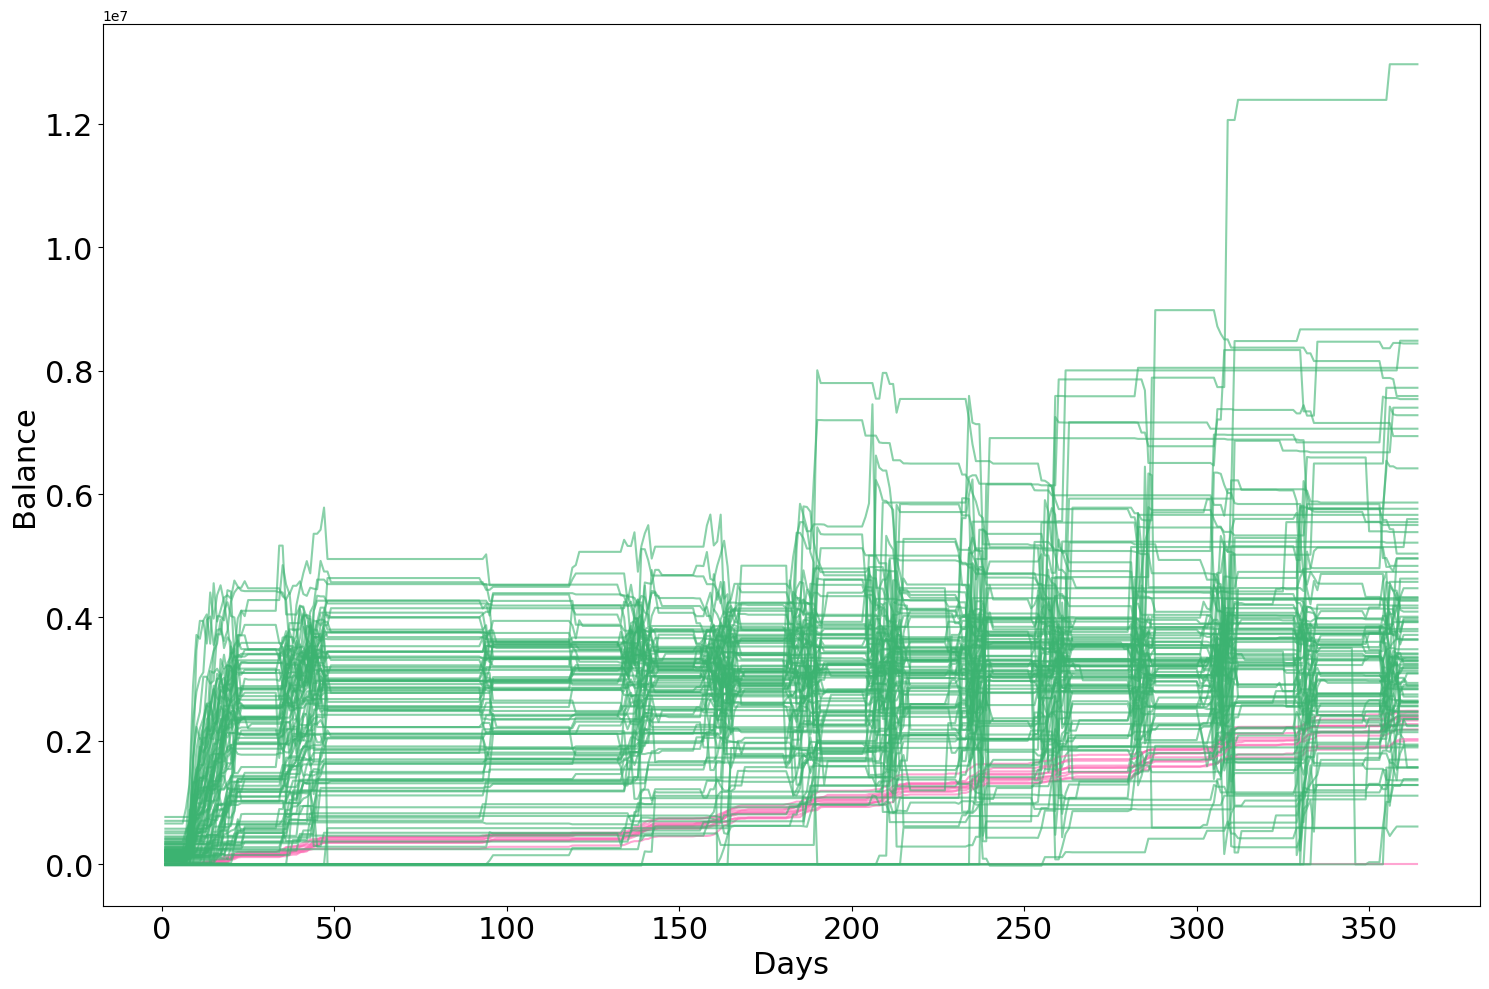

In [7]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    color = 'mediumseagreen' if user.startswith('C') else 'hotpink'

    plt.plot(balance_df.index, balance_df[user], color=color, label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

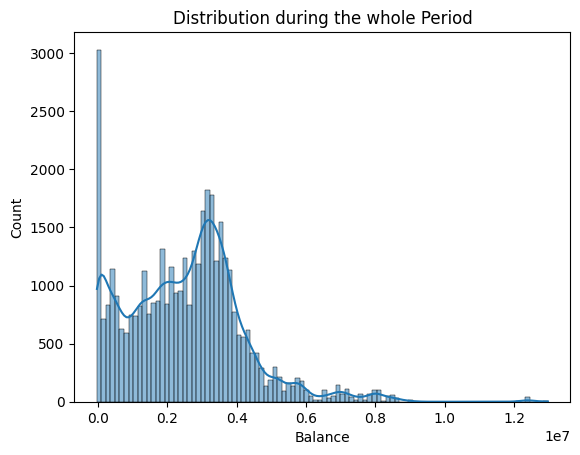

In [8]:
values_df = balance_df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

In [9]:
balance_df.T

,1,2,3,4,5,6,7,8,9,10,...,355,356,357,358,359,360,361,362,363,364
C1000631618,107129.61,107129.61,107129.61,107129.61,107129.61,107129.61,107129.61,107129.61,512481.76,799405.17,...,3081104.69,2932202.19,2885341.03,2930984.21,2930984.21,2718063.80,2718063.80,2718063.80,2718063.80,2718063.80
M7146327871,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1892360.99,1913390.87,1954961.06,1988961.38,1988961.38,1990739.78,2004680.48,2004680.48,2004680.48,2004680.48
C9621947975,131604.72,131604.72,131604.72,131604.72,131604.72,131604.72,131604.72,373754.15,731821.37,731821.37,...,3478059.72,3501554.13,3501554.13,3485069.81,3485069.81,3485069.81,3485069.81,3485069.81,3485069.81,3485069.81
M3557595485,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,2280567.87,2332442.18,2361648.18,2388854.99,2409646.25,2409646.25,2409646.25,2409646.25,2409646.25,2409646.25
C9301748160,80436.55,80436.55,80436.55,80436.55,80436.55,80436.55,99156.55,885095.87,885095.87,1050918.58,...,4574234.06,4554881.98,4434499.10,4434499.10,4123403.32,4094414.49,4094414.49,4094414.49,4094414.49,4094414.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CC1010384077,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86,4313174.86
CC8841157157,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,2249334.87,2249334.87,2249334.87,2249334.87,2753311.34,2753311.34,2753311.34,2753311.34,2753311.34,2753311.34
CC0584867436,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98,1285822.98
CC3222417434,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00,1567009.00


# SQUIC

In [10]:
df = balance_df

In [11]:
ROWS = len(df.iloc[0])
ROWS

111

## Non-Normalization

In [12]:
Y = df.T.to_numpy()  # Transpose to get shape (users, days)
#l = [1e5, 3e5, 5e5, 7e5, 9e5, 11e5, 13e5, 15e5, 17e5, 19e5]

l = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7]

In [13]:
print(np.isnan(Y).sum())  # should be 0 (no NaN)
print(np.linalg.matrix_rank(Y))  # should be full rank (ideally)
print(np.linalg.cond(Y))  # condition number; high = bad

0
110
2.1434566810147684e+19


In [14]:
squic_dict = {}

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=8.29e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.68e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.52e-02 nnz(X,W)/p=[1.09e+02 1.67e+01] 

time required: 0.02 seconds
For rho = 1e-05 there are so

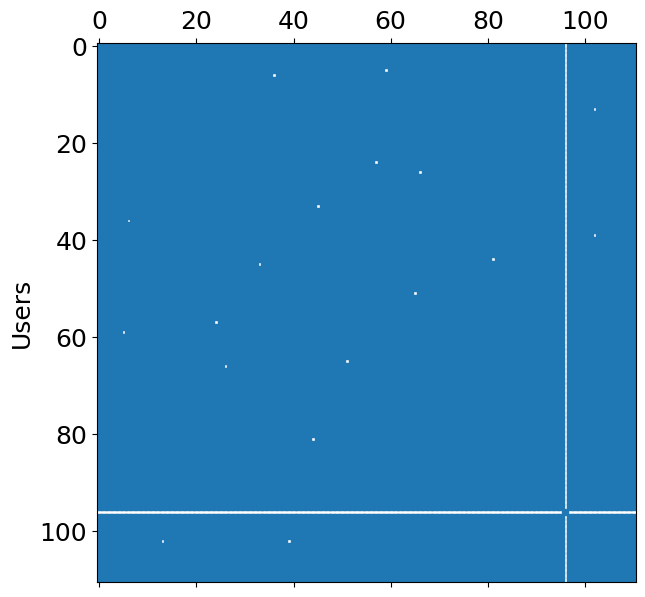

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 1e-05
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.10e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.80e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.48e-02 nnz(X,W)/p=[

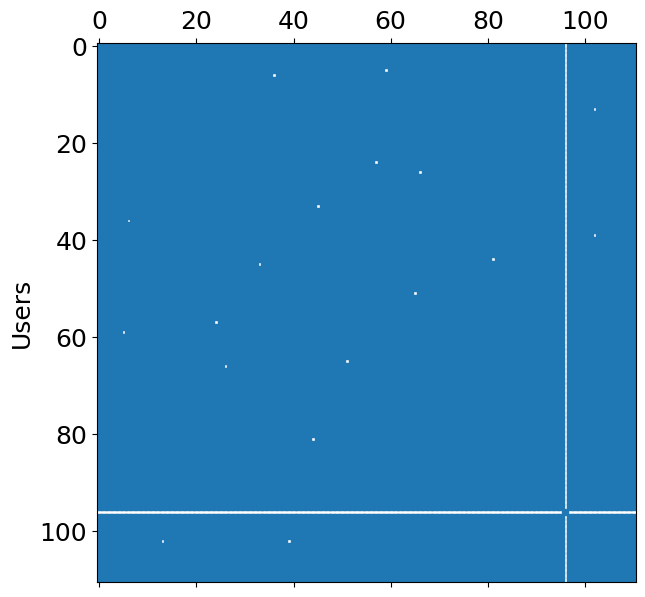

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 0.0001
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.27e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.78e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.48e-02 nnz(X,W)/p=

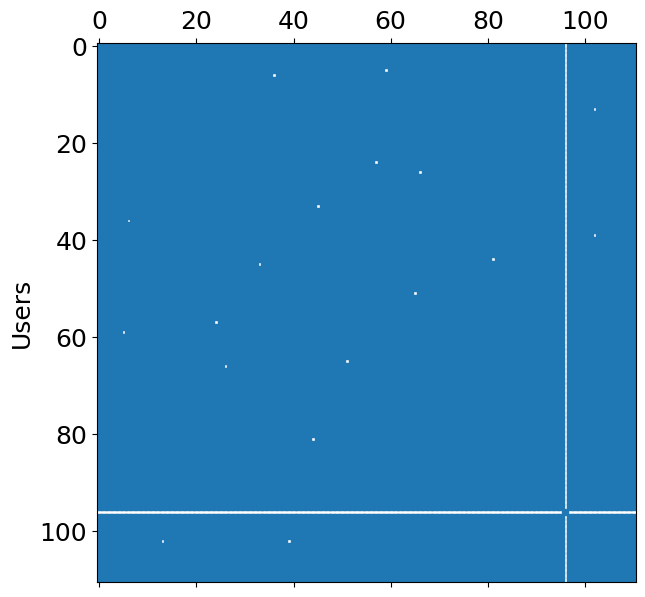

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 0.001
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.86e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.75e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.49e-02 nnz(X,W)/p=[

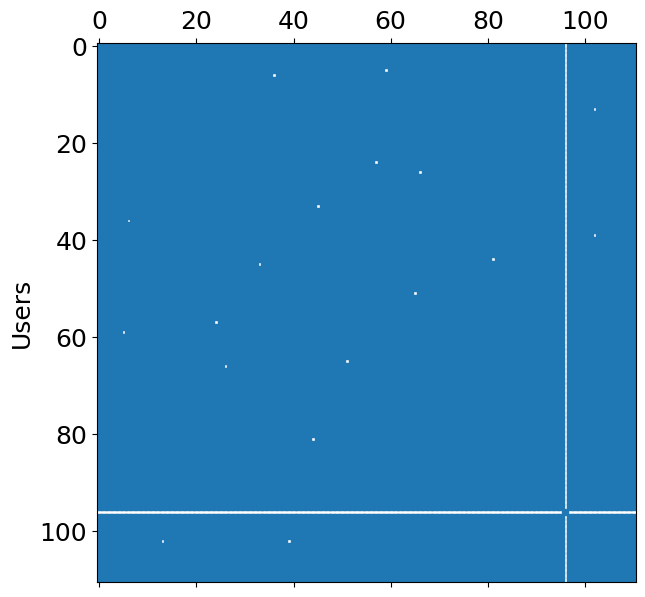

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 0.01
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.62e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.83e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.48e-02 nnz(X,W)/p=[1

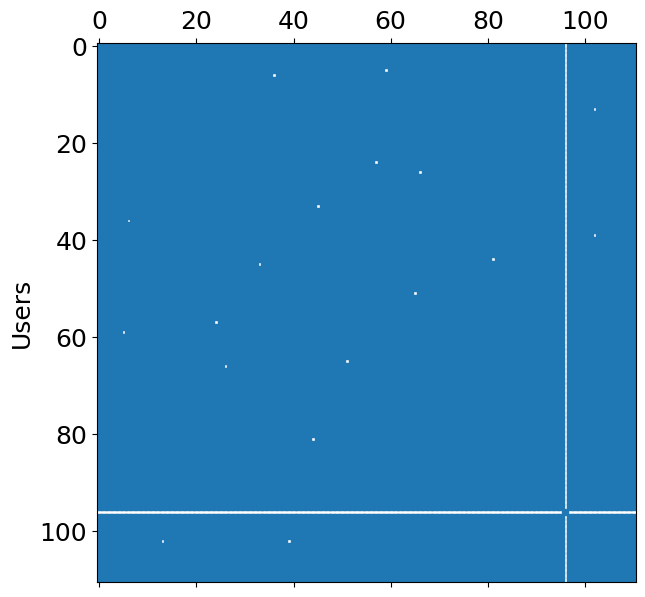

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 0.1
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.43e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.80e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.48e-02 nnz(X,W)/p=[1.

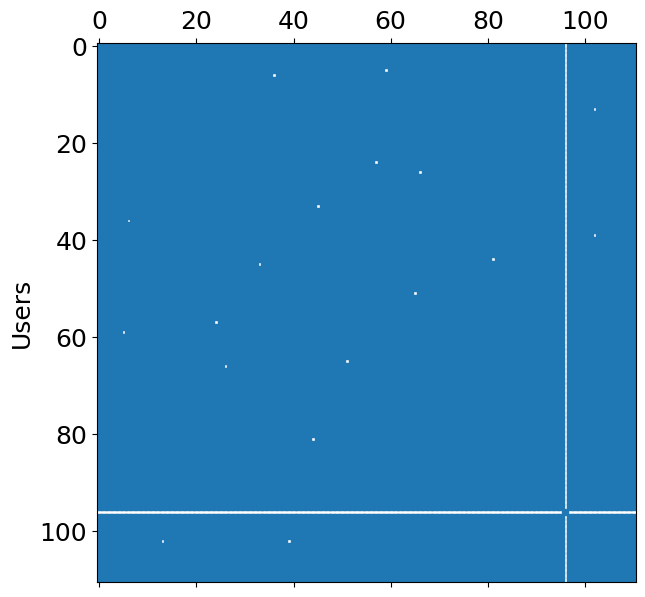

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 10.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.81e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.91e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.52e-02 nnz(X,W)/p=[1

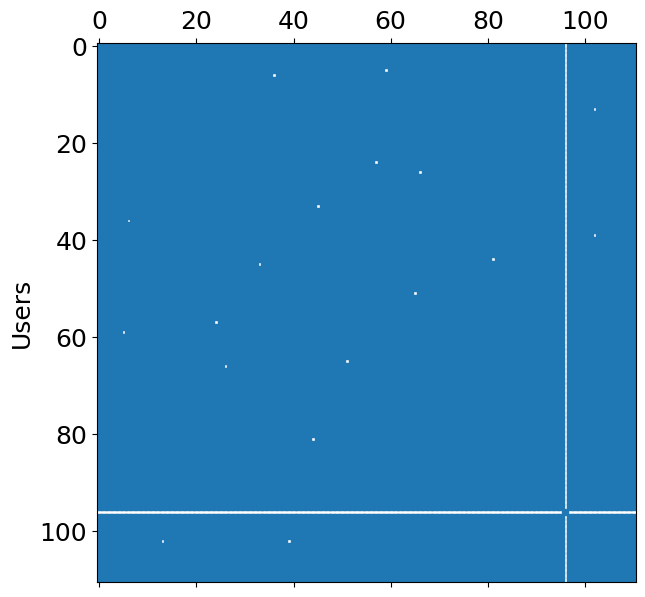

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 100.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.59e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.88e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.49e-02 nnz(X,W)/p=[

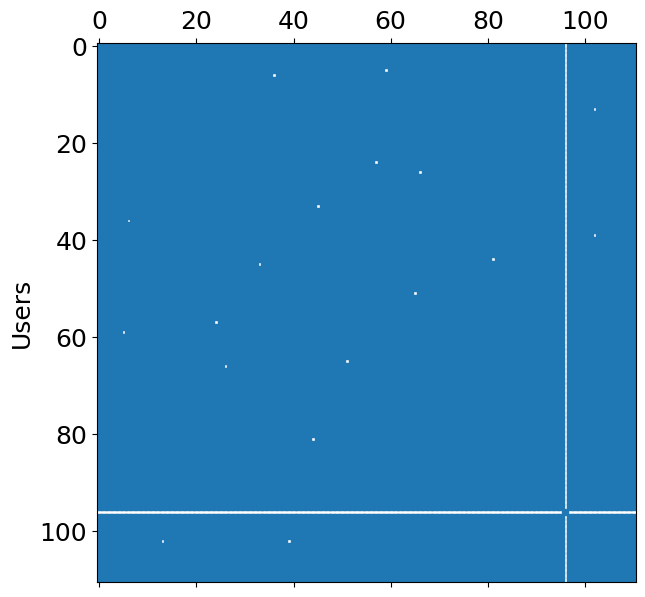

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 1000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.49e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.82e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.49e-02 nnz(X,W)/p=

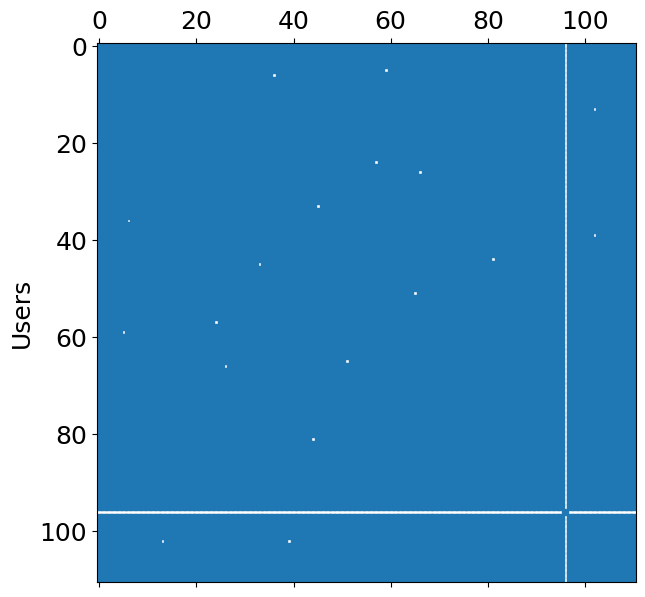

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 10000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.49e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.87e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.50e-02 nnz(X,W)/p

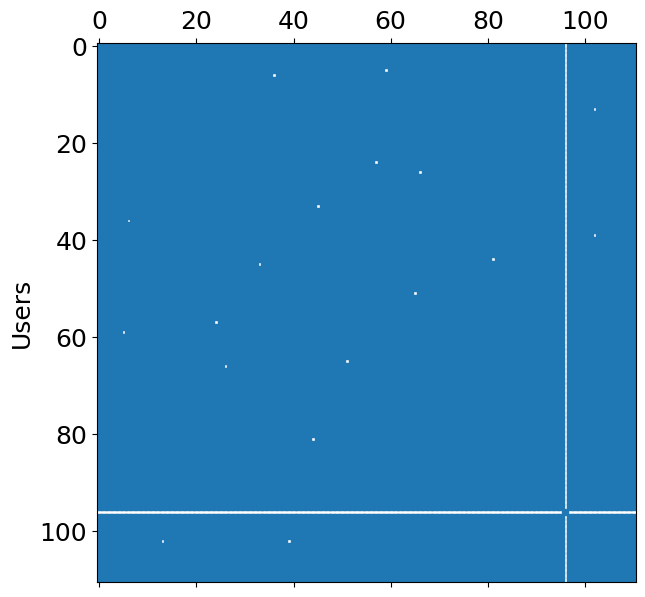

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 100000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.48e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.84e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.50e-02 nnz(X,W)/

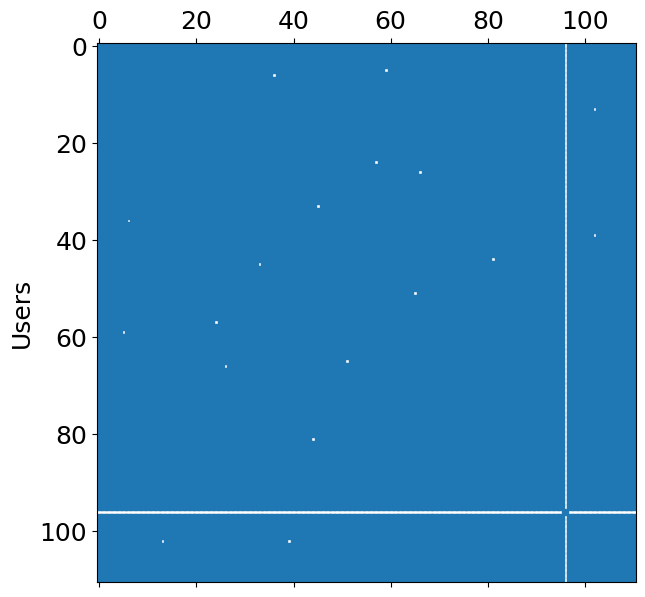

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 1000000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+07 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.65e-04 nnz(S)/p=1.09e+02
* iter=1 time=4.62e-03 obj=6.62e+13 |delta(obj)|/obj=1.95e+00 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.67e+01] lns_iter=48 
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=1.47e-02 nnz(X,W)

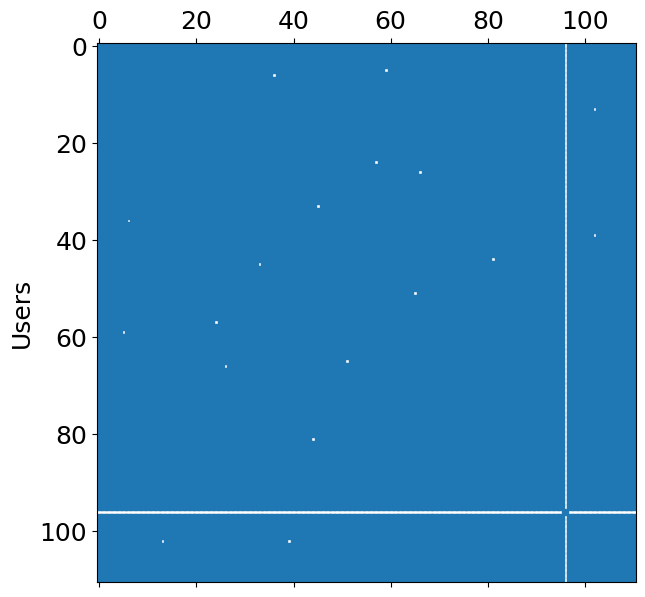

nnz = 12083
nnz/row = 108.85585585585585
✅ Matrix is symmetric per rho 10000000.0


In [15]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    X, computation_time = compute_squic(Y, rho)
    computation_time = round(computation_time, 2)
    squic_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_dict[rho], ROWS)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(squic_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        sparsity_pattern(squic_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(squic_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        if is_symmetric(squic_dict[rho]):
            print(f"✅ Matrix is symmetric per rho {rho}")
        else:
            print(f"❌ Matrix is not symmetric per rho {rho}")
        

data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

## Normalization

In [16]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_9191/3409128255.py:3: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation


In [17]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", np.mean(np.std(Y_new, axis=1)))

NaNs? True
Infs? False
Max: nan
Min: nan
Mean std per row (should be 1): nan


In [18]:
stds = np.std(Y, axis=1)
safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
Y_new = np.diag(1 / safe_stds) @ Y

print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", np.mean(np.std(Y_new, axis=1)))

NaNs? False
Infs? False
Max: 8.543118154566585
Min: -0.07105855643795057
Mean std per row (should be 1): 0.9909909909909909


In [19]:
print(np.linalg.cond(Y_new))  # condition number; high = bad

7.834216346251813e+19


In [20]:
# l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]
l = [1e-3, 1e-2, 2e-2, 5e-2, 9e-2, 1e-1, 2e-1, 5e-1, 9e-1]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.12e-04 nnz(S)/p=1.09e+02
* iter=1 time=2.53e-03 obj=6.55e+01 |delta(obj)|/obj=6.80e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.35e-03 obj=5.60e+01 |delta(obj)|/obj=1.69e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.02e+02] lns_iter=9 
* iter=3 time=4.35e-02 obj=3.86e+01 |delta(obj)|/ob

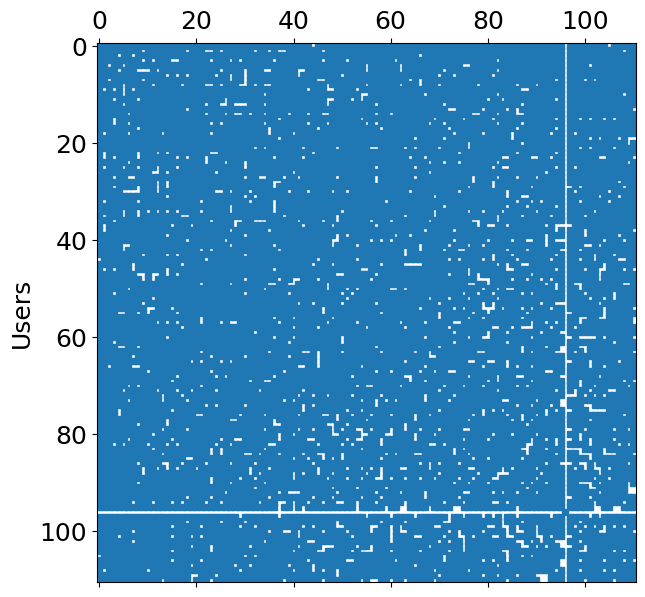

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.50e-04 nnz(S)/p=1.07e+02
* iter=1 time=2.64e-03 obj=6.78e+01 |delta(obj)|/obj=6.22e-01 nnz(X,L,W)/p=[1.07e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.60e-03 obj=5.85e+01 |delta(obj)|/obj=1.60e-01 nnz(X,L,W)/p=[1.07e+02 5.45e+01 1.02e+02] lns_iter=9 
* iter=3 time=4.31e-02 obj=4.15e+01 |delta(obj)|/ob

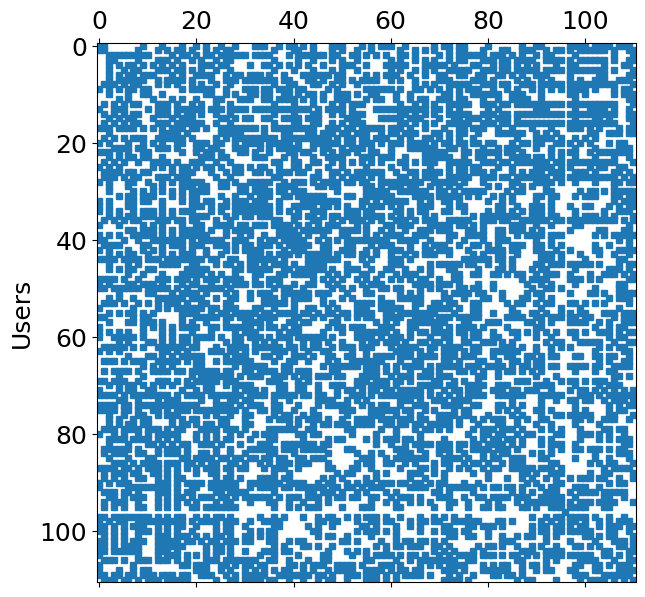

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.64e-04 nnz(S)/p=1.06e+02
* iter=1 time=2.90e-03 obj=7.04e+01 |delta(obj)|/obj=5.63e-01 nnz(X,L,W)/p=[1.06e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.78e-03 obj=6.12e+01 |delta(obj)|/obj=1.49e-01 nnz(X,L,W)/p=[1.06e+02 5.45e+01 1.01e+02] lns_iter=9 
* iter=3 time=4.29e-02 obj=4.49e+01 |delta(obj)|/ob

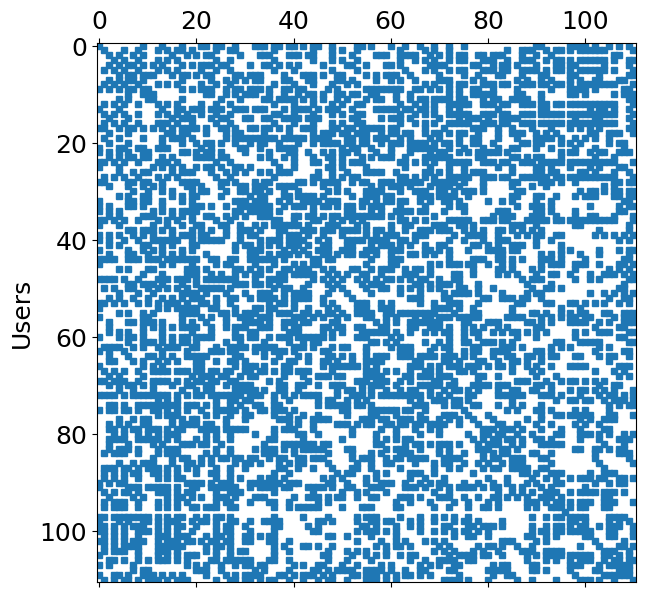

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.56e-04 nnz(S)/p=1.01e+02
* iter=1 time=2.82e-03 obj=7.78e+01 |delta(obj)|/obj=4.14e-01 nnz(X,L,W)/p=[1.01e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.36e-03 obj=6.93e+01 |delta(obj)|/obj=1.22e-01 nnz(X,L,W)/p=[1.01e+02 5.45e+01 1.01e+02] lns_iter=9 
* iter=3 time=3.83e-02 obj=5.44e+01 |delta(obj)|/ob

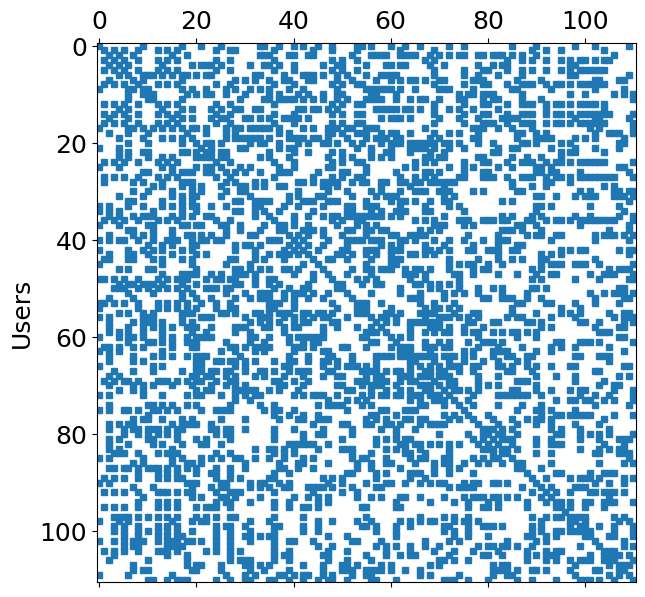

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.77e-04 nnz(S)/p=9.43e+01
* iter=1 time=2.56e-03 obj=8.73e+01 |delta(obj)|/obj=2.60e-01 nnz(X,L,W)/p=[9.43e+01 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.89e-03 obj=7.34e+01 |delta(obj)|/obj=1.90e-01 nnz(X,L,W)/p=[9.43e+01 5.45e+01 1.08e+02] lns_iter=8 
* iter=3 time=3.89e-02 obj=6.41e+01 |delta(obj)|/ob

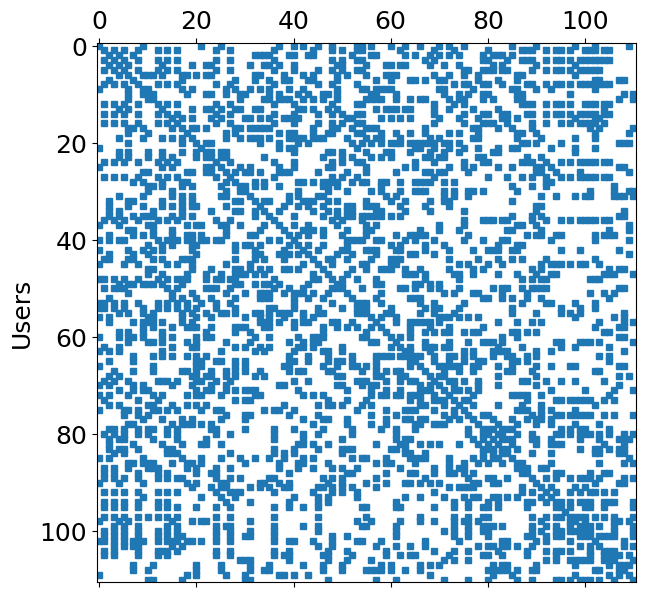

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.92e-04 nnz(S)/p=9.29e+01
* iter=1 time=2.61e-03 obj=8.96e+01 |delta(obj)|/obj=2.28e-01 nnz(X,L,W)/p=[9.29e+01 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.84e-03 obj=7.59e+01 |delta(obj)|/obj=1.81e-01 nnz(X,L,W)/p=[9.29e+01 5.45e+01 1.07e+02] lns_iter=8 
* iter=3 time=3.61e-02 obj=6.69e+01 |delta(obj)|/ob

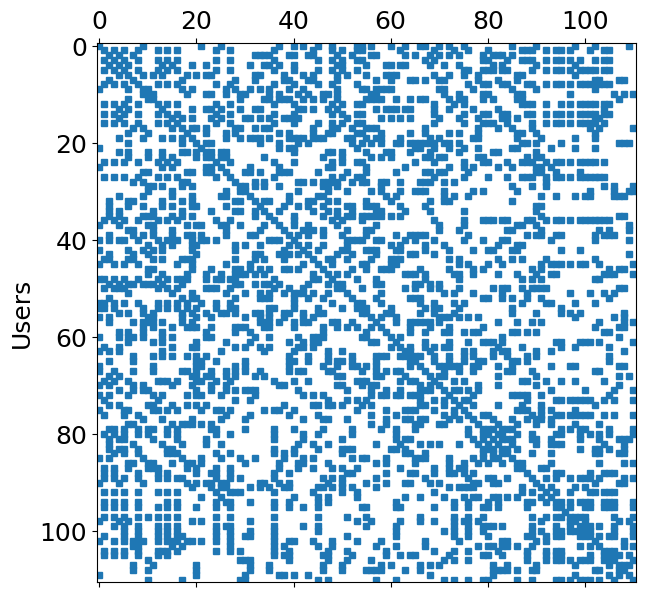

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.07e-04 nnz(S)/p=7.79e+01
* iter=1 time=2.76e-03 obj=1.11e+02 |delta(obj)|/obj=7.31e-03 nnz(X,L,W)/p=[7.79e+01 5.29e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.30e-03 obj=1.01e+02 |delta(obj)|/obj=9.89e-02 nnz(X,L,W)/p=[7.79e+01 5.29e+01 1.09e+02] lns_iter=8 
* iter=3 time=2.68e-02 obj=9.18e+01 |delta(obj)|/ob

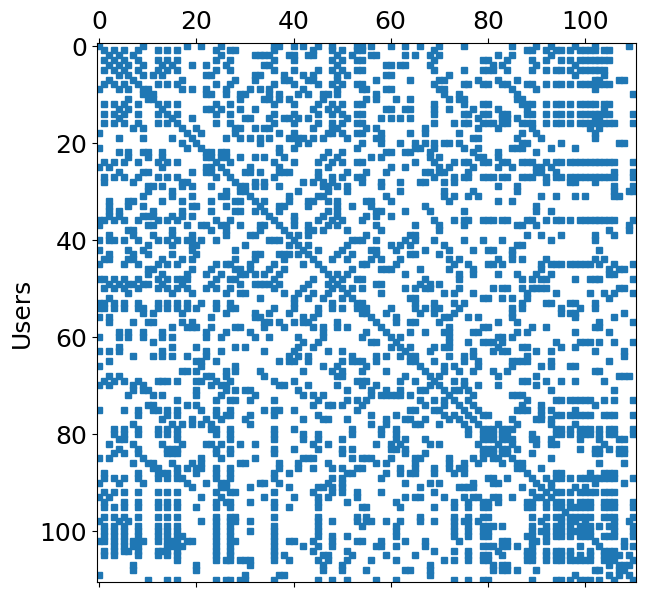

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.33e-04 nnz(S)/p=3.98e+01
* iter=1 time=1.68e-03 obj=1.55e+02 |delta(obj)|/obj=2.93e-01 nnz(X,L,W)/p=[3.98e+01 3.40e+01 1.00e+00] lns_iter=6 
* iter=2 time=2.82e-03 obj=1.51e+02 |delta(obj)|/obj=2.87e-02 nnz(X,L,W)/p=[3.98e+01 3.40e+01 4.14e+01] lns_iter=7 
* iter=3 time=8.14e-03 obj=1.44e+02 |delta(obj)|/ob

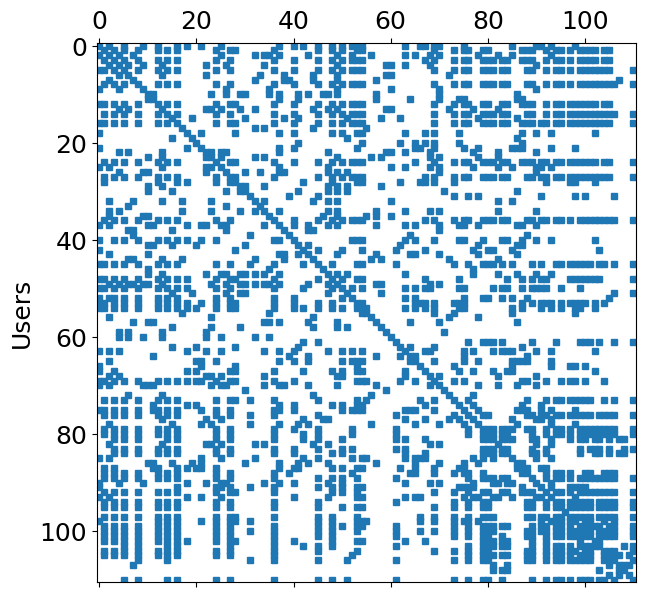

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.12e-04 nnz(S)/p=7.07e+00
* iter=1 time=1.12e-03 obj=1.91e+02 |delta(obj)|/obj=4.23e-01 nnz(X,L,W)/p=[7.07e+00 5.07e+00 1.00e+00] lns_iter=3 
* iter=2 time=1.48e-03 obj=1.86e+02 |delta(obj)|/obj=2.68e-02 nnz(X,L,W)/p=[7.07e+00 5.07e+00 8.84e+00] lns_iter=3 
* iter=3 time=1.97e-03 obj=1.82e+02 |delta(obj)|/ob

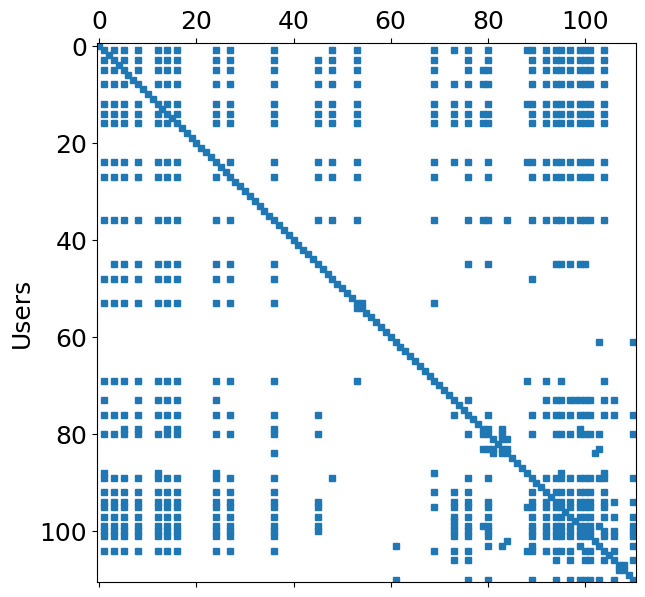

In [21]:
squic_norm_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_norm_dict[rho], ROWS)

    if is_symmetric(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    data_nnz.append(nonz)
    data_nnzr.append(round(nonz_r, 2))
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(squic_norm_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        # sparsity_pattern(rho_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        sparsity_pattern(squic_norm_dict[rho])


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit

In [22]:
fit_norm_dict = {}

In [23]:
Y = df.T.to_numpy()  # Convert to (users, days)

# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_9191/1629358900.py:4: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation


In [24]:
stds = np.std(Y, axis=1)
safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
Y_new = np.diag(1 / safe_stds) @ Y

In [25]:
l = [1e-3, 1e-2, 2e-2, 5e-2, 9e-2, 1e-1, 2e-1, 5e-1, 9e-1]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.24e-04 nnz(S)/p=1.09e+02
* iter=1 time=2.67e-03 obj=6.55e+01 |delta(obj)|/obj=6.80e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.87e-03 obj=5.60e+01 |delta(obj)|/obj=1.69e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.02e+02] lns_iter=9 
* iter=3 time=4.30e-02 obj=3.86e+01 |delta(obj)|/ob

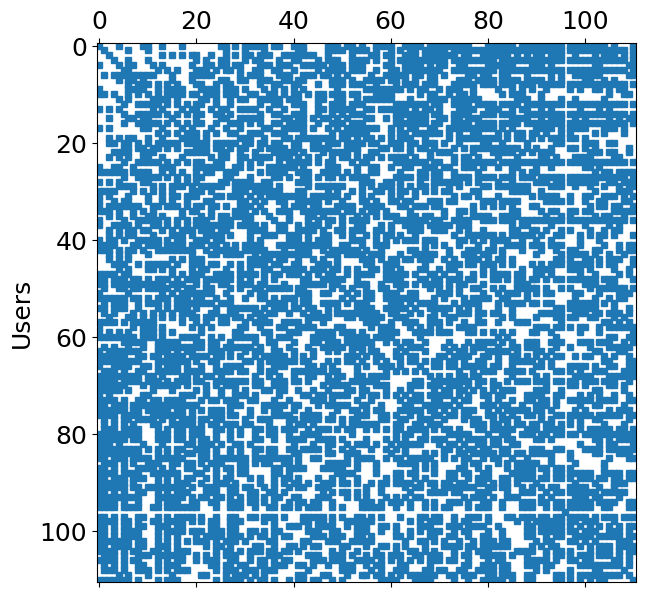

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.14e-04 nnz(S)/p=1.07e+02
* iter=1 time=2.60e-03 obj=6.78e+01 |delta(obj)|/obj=6.22e-01 nnz(X,L,W)/p=[1.07e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.57e-03 obj=5.85e+01 |delta(obj)|/obj=1.60e-01 nnz(X,L,W)/p=[1.07e+02 5.45e+01 1.02e+02] lns_iter=9 
* iter=3 time=4.29e-02 obj=4.15e+01 |delta(obj)|/ob

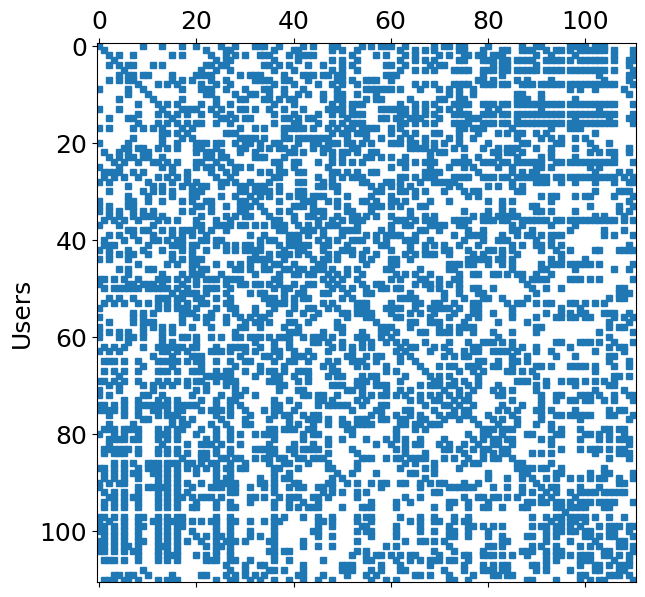

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.49e-04 nnz(S)/p=1.06e+02
* iter=1 time=2.73e-03 obj=7.04e+01 |delta(obj)|/obj=5.63e-01 nnz(X,L,W)/p=[1.06e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.32e-03 obj=6.12e+01 |delta(obj)|/obj=1.49e-01 nnz(X,L,W)/p=[1.06e+02 5.45e+01 1.01e+02] lns_iter=9 
* iter=3 time=4.21e-02 obj=4.49e+01 |delta(obj)|/ob

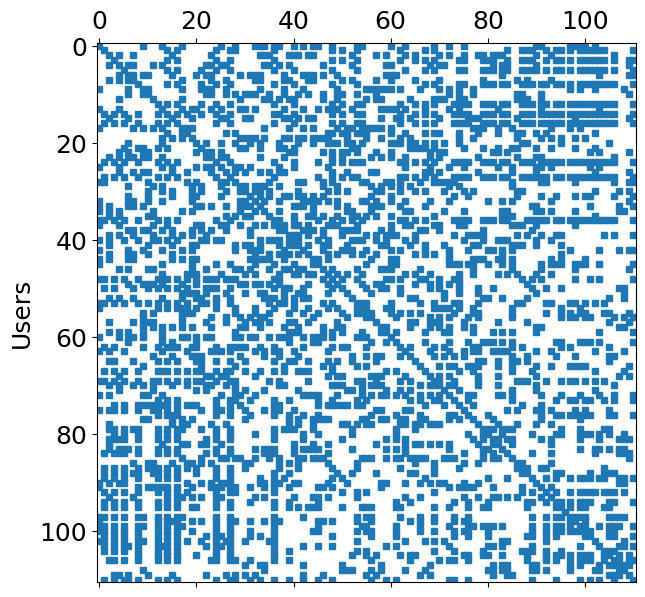

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.39e-04 nnz(S)/p=1.01e+02
* iter=1 time=2.76e-03 obj=7.78e+01 |delta(obj)|/obj=4.14e-01 nnz(X,L,W)/p=[1.01e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=5.29e-03 obj=6.93e+01 |delta(obj)|/obj=1.22e-01 nnz(X,L,W)/p=[1.01e+02 5.45e+01 1.01e+02] lns_iter=9 
* iter=3 time=3.86e-02 obj=5.44e+01 |delta(obj)|/ob

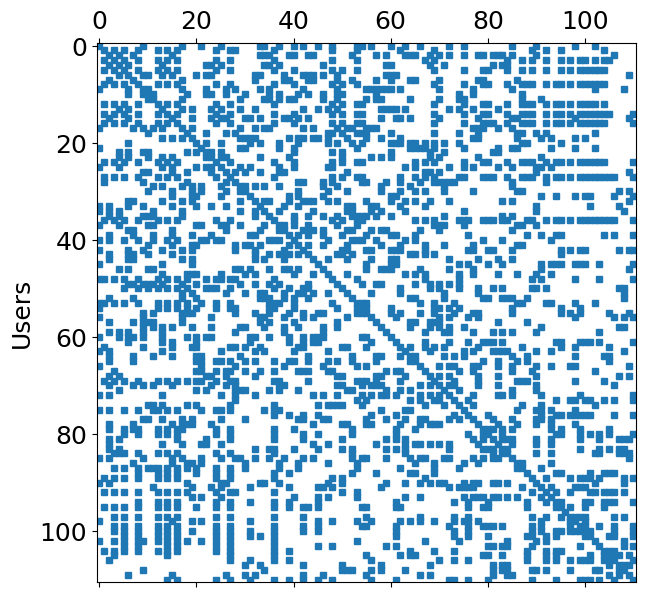

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.99e-04 nnz(S)/p=9.43e+01
* iter=1 time=2.76e-03 obj=8.73e+01 |delta(obj)|/obj=2.60e-01 nnz(X,L,W)/p=[9.43e+01 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.94e-03 obj=7.34e+01 |delta(obj)|/obj=1.90e-01 nnz(X,L,W)/p=[9.43e+01 5.45e+01 1.08e+02] lns_iter=8 
* iter=3 time=3.88e-02 obj=6.41e+01 |delta(obj)|/ob

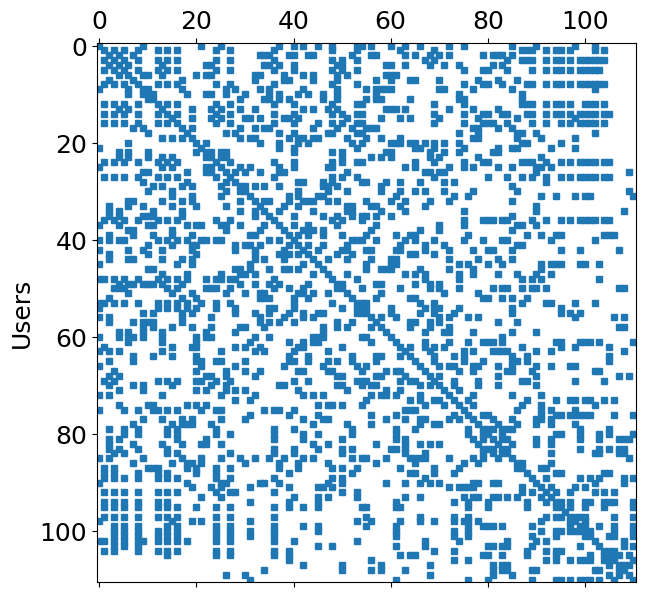

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.24e-04 nnz(S)/p=9.29e+01
* iter=1 time=2.77e-03 obj=8.96e+01 |delta(obj)|/obj=2.28e-01 nnz(X,L,W)/p=[9.29e+01 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.54e-03 obj=7.59e+01 |delta(obj)|/obj=1.81e-01 nnz(X,L,W)/p=[9.29e+01 5.45e+01 1.07e+02] lns_iter=8 
* iter=3 time=3.58e-02 obj=6.69e+01 |delta(obj)|/ob

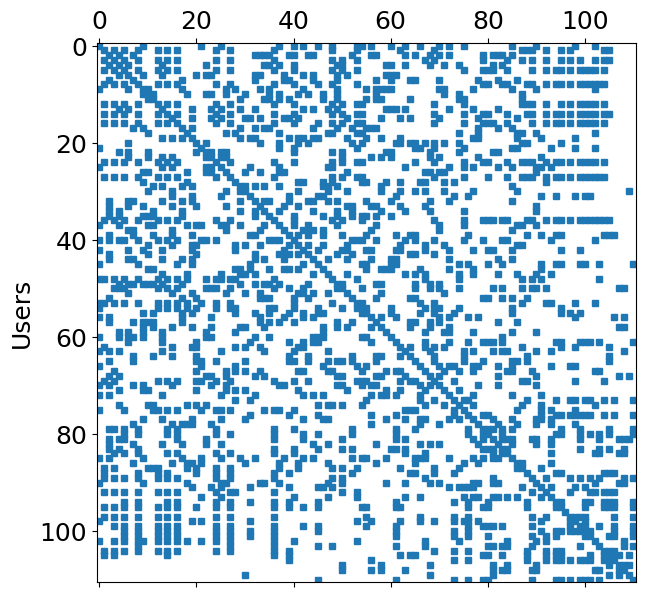

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.26e-04 nnz(S)/p=7.79e+01
* iter=1 time=2.53e-03 obj=1.11e+02 |delta(obj)|/obj=7.31e-03 nnz(X,L,W)/p=[7.79e+01 5.29e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.33e-03 obj=1.01e+02 |delta(obj)|/obj=9.89e-02 nnz(X,L,W)/p=[7.79e+01 5.29e+01 1.09e+02] lns_iter=8 
* iter=3 time=2.67e-02 obj=9.18e+01 |delta(obj)|/ob

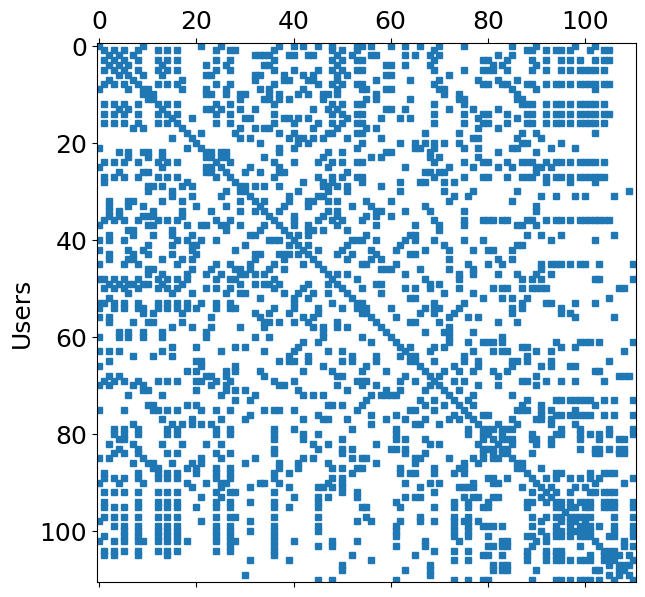

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.06e-04 nnz(S)/p=3.98e+01
* iter=1 time=1.75e-03 obj=1.55e+02 |delta(obj)|/obj=2.93e-01 nnz(X,L,W)/p=[3.98e+01 3.40e+01 1.00e+00] lns_iter=6 
* iter=2 time=2.56e-03 obj=1.51e+02 |delta(obj)|/obj=2.87e-02 nnz(X,L,W)/p=[3.98e+01 3.40e+01 4.14e+01] lns_iter=7 
* iter=3 time=8.23e-03 obj=1.44e+02 |delta(obj)|/ob

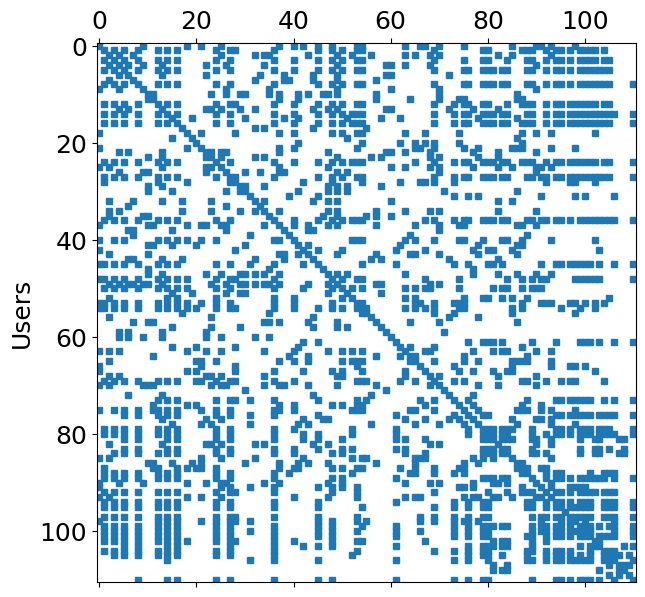

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.64e-04 nnz(S)/p=7.07e+00
* iter=1 time=9.69e-04 obj=1.91e+02 |delta(obj)|/obj=4.23e-01 nnz(X,L,W)/p=[7.07e+00 5.07e+00 1.00e+00] lns_iter=3 
* iter=2 time=1.40e-03 obj=1.86e+02 |delta(obj)|/obj=2.68e-02 nnz(X,L,W)/p=[7.07e+00 5.07e+00 8.84e+00] lns_iter=3 
* iter=3 time=1.87e-03 obj=1.82e+02 |delta(obj)|/ob

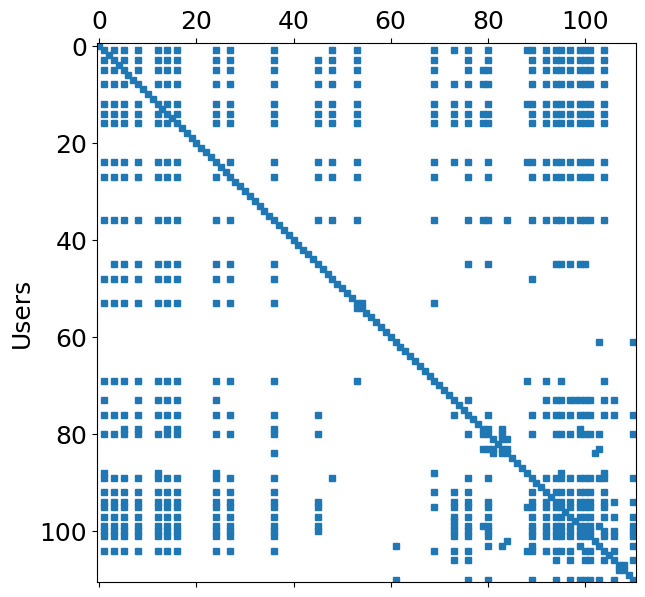

In [26]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit(Y_new, lambda_val=rho, eta=rho * 0.1)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")
    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    if is_symmetric(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    sparsity_pattern(fit_norm_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(round(nnz_r, 2))
    data_time.append(end_time)

table_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# Table

In [27]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [28]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit, "SQUIC FIT NORM", l))

╒══════════════╤═════════╤════════╤════════╤════════╤════════╤═══════╤═══════╤═══════╤═══════╕
│  SQUIC NORM  │  0.001  │  0.01  │  0.02  │  0.05  │  0.09  │  0.1  │  0.2  │  0.5  │  0.9  │
╞══════════════╪═════════╪════════╪════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╡
│     NNZ      │  10627  │  5885  │  4775  │  3461  │  2991  │ 2889  │ 2633  │ 2339  │  749  │
├──────────────┼─────────┼────────┼────────┼────────┼────────┼───────┼───────┼───────┼───────┤
│   NNZ/Row    │  95.74  │ 53.02  │ 43.02  │ 31.18  │ 26.95  │ 26.03 │ 23.72 │ 21.07 │ 6.75  │
├──────────────┼─────────┼────────┼────────┼────────┼────────┼───────┼───────┼───────┼───────┤
│   Time (s)   │  35.06  │  7.67  │  3.41  │  1.59  │  1.47  │ 0.88  │ 0.23  │ 0.04  │ 0.01  │
├──────────────┼─────────┼────────┼────────┼────────┼────────┼───────┼───────┼───────┼───────┤
│  Symmetric   │   Yes   │  Yes   │  Yes   │  Yes   │  Yes   │  Yes  │  Yes  │  Yes  │  Yes  │
╘══════════════╧═════════╧════════╧════════╧══════